In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200

prices = (
    100 +
    np.cumsum(
        np.random.normal(
            0.2,
            1,
            n
        )
    )
)

volume = np.random.randint(
    1000,
    5000,
    n
)

df = pd.DataFrame({
    "Close": prices,
    "Volume": volume
})

df.head()

,Close,Volume
0,100.696714,2409
1,100.758450,1784
2,101.606138,4175
3,103.329168,4464
4,103.295015,4882


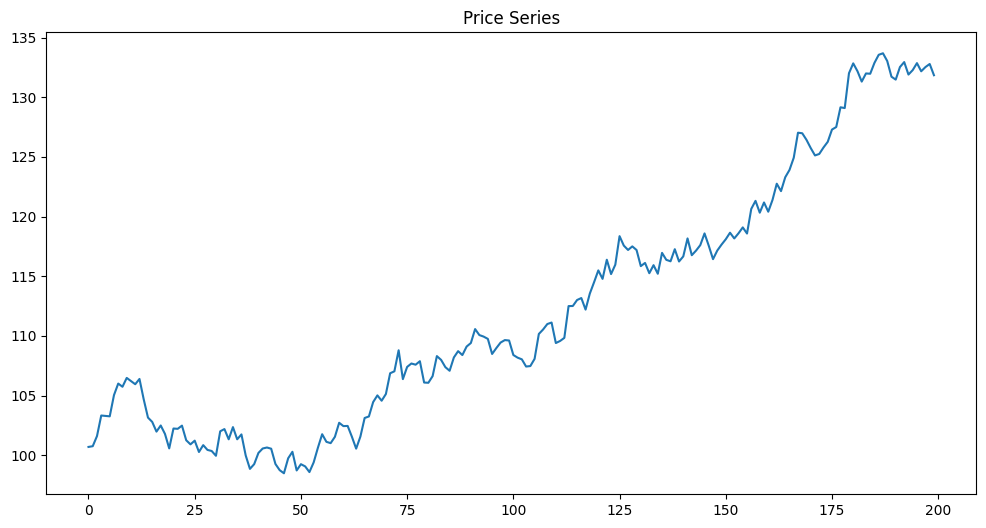

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df["Close"])

plt.title("Price Series")

plt.show()

In [ ]:
df["MA10"] = (
    df["Close"]
    .rolling(10)
    .mean()
)

df["MA50"] = (
    df["Close"]
    .rolling(50)
    .mean()
)

df["Momentum"] = np.where(
    df["Close"] > df["MA10"],
    1,
    0
)
df["Momentum1"] = np.where(
    df["MA10"] > df["MA50"],
    1,
    0
)

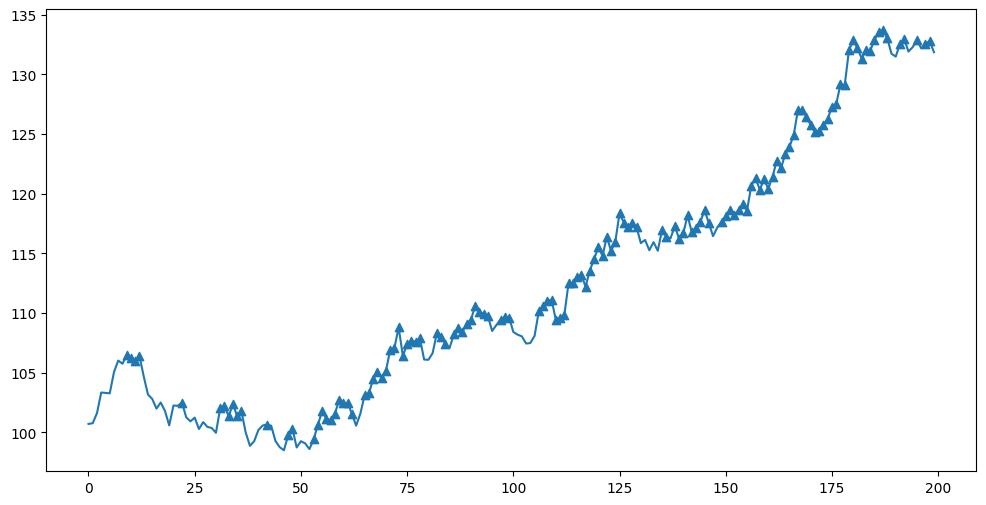

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(df["Close"])

buy_points = df[
    df["Momentum"] == 1
]

plt.scatter(
    buy_points.index,
    buy_points["Close"],
    marker="^"
)

plt.show()

In [ ]:
df["MA20"] = (
    df["Close"]
    .rolling(20)
    .mean()
)

df["MeanRev"] = np.where(
    df["Close"]
    <
    0.95 * df["MA20"],
    1,
    0
)

In [ ]:
df["AvgVolume"] = (
    df["Volume"]
    .rolling(20)
    .mean()
)

df["VolSpike"] = np.where(
    df["Volume"]
    >
    1.5 * df["AvgVolume"],
    1,
    0
)

In [ ]:
print(
    "Momentum:",
    df["Momentum"].sum()
)

print(
    "Mean Reversion:",
    df["MeanRev"].sum()
)

print(
    "Volume:",
    df["VolSpike"].sum()
)

Momentum: 133
Mean Reversion: 0
Volume: 19


Next Lecture

In [ ]:
df["Return"] = (
    df["Close"]
    .pct_change()
)

In [ ]:
df["Strategy_Return"] = (
    df["Momentum"]
    .shift(1)
    *
    df["Return"]
)

In [ ]:
wins = (
    df["Strategy_Return"]
    > 0
).sum()

total = (
    df["Strategy_Return"]
    .count()
)

hit_rate = wins / total

print(hit_rate)

0.36683417085427134


In [ ]:
avg_return = (
    df["Strategy_Return"]
    .mean()
)

print(avg_return)

0.0005080808990807999


In [ ]:
df["Cumulative"] = (
    1 +
    df["Strategy_Return"]
).cumprod()

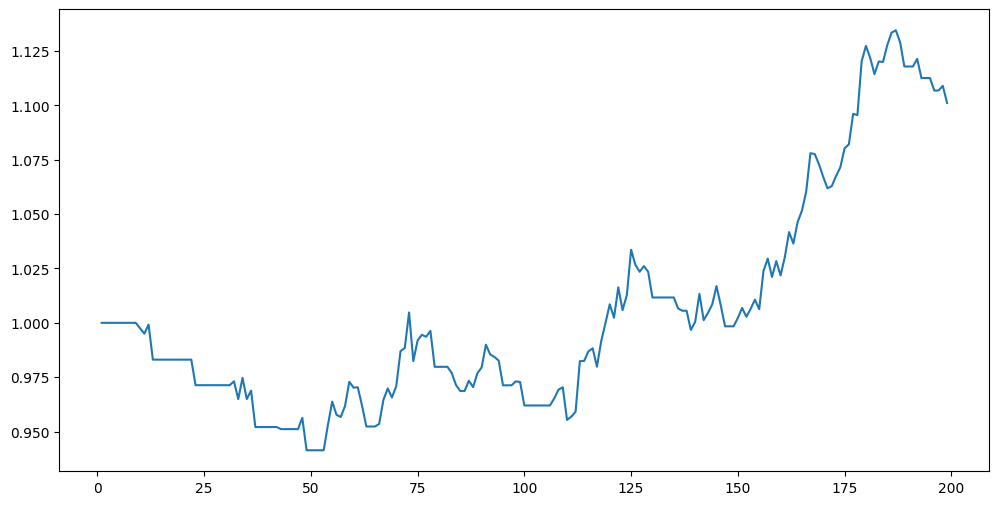

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Cumulative"]
)

plt.show()

In [ ]:
cost = 0.0005

df["Net_Return"] = (
    df["Strategy_Return"]
    - cost
)

df["Net_Cumulative"] = (
    1 +
    df["Net_Return"]
).cumprod()

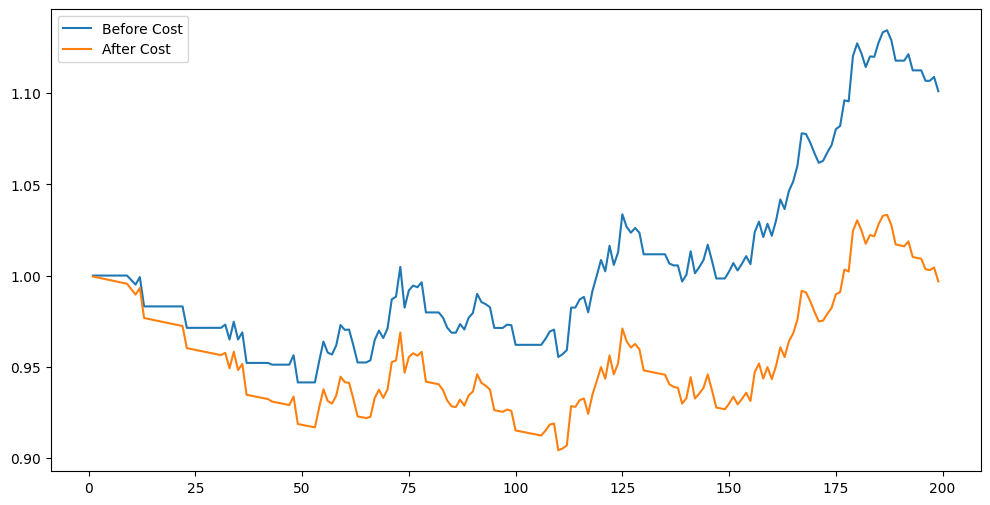

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Cumulative"],
    label="Before Cost"
)

plt.plot(
    df["Net_Cumulative"],
    label="After Cost"
)

plt.legend()

plt.show()